 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset Loaded!")
print(df.shape)
df.head()

Dataset Loaded!
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2. Inspect Dataset

In [2]:
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

3. Find Missing Values

In [3]:
print(df.isnull().sum())

missing_pct = (df.isnull().sum()/len(df))*100

print("\nMissing Percentage")
print(missing_pct.round(2))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Percentage
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


4.Clean Dataset

In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_842/2165889813.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_842/2165889813.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

5. Remove Duplicates

In [5]:
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

print(df.shape)

Duplicates Before: 0
Duplicates After: 0
(891, 11)


6. Exploratory Analysis

In [6]:
print("Survival Count")
print(df['Survived'].value_counts())

print("\nSurvival Rate")
print(df['Survived'].mean()*100)

print("\nAverage Age by Class")
print(df.groupby('Pclass')['Age'].mean())

print("\nSurvival by Gender")
print(df.groupby('Sex')['Survived'].mean()*100)

Survival Count
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate
38.38383838383838

Average Age by Class
Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

Survival by Gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


7. Create New Columns

In [7]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize']==1).astype(int)

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Young Adult


8. Save Cleaned Dataset

In [8]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Saved Successfully")

Saved Successfully


In [9]:
from google.colab import files
files.download("titanic_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualizations

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

Chart 1: Survival by Gender

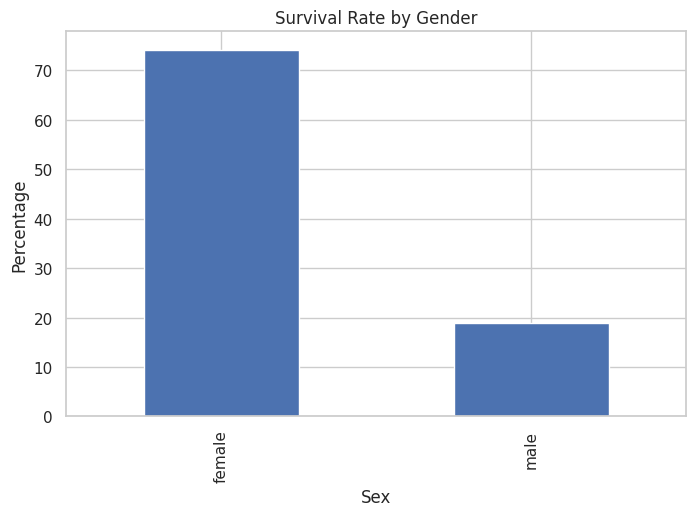

In [11]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()*100

plt.figure(figsize=(8,5))
survival_by_sex.plot(kind='bar')

plt.title("Survival Rate by Gender")
plt.ylabel("Percentage")
plt.savefig("chart1_survival_by_gender.png")
plt.show()

Chart 2: Age Distribution

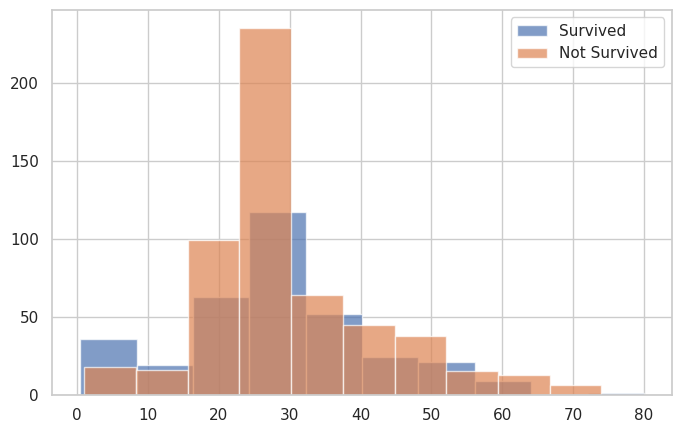

In [12]:
plt.figure(figsize=(8,5))

df[df['Survived']==1]['Age'].hist(alpha=0.7,label='Survived')
df[df['Survived']==0]['Age'].hist(alpha=0.7,label='Not Survived')

plt.legend()
plt.savefig("chart2_age_distribution.png")
plt.show()

Chart 3: Passenger Class Pie Chart

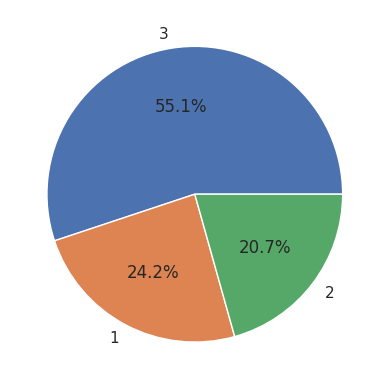

In [13]:
df['Pclass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.savefig("chart3_class_distribution.png")
plt.show()

Chart 4: Fare Boxplot

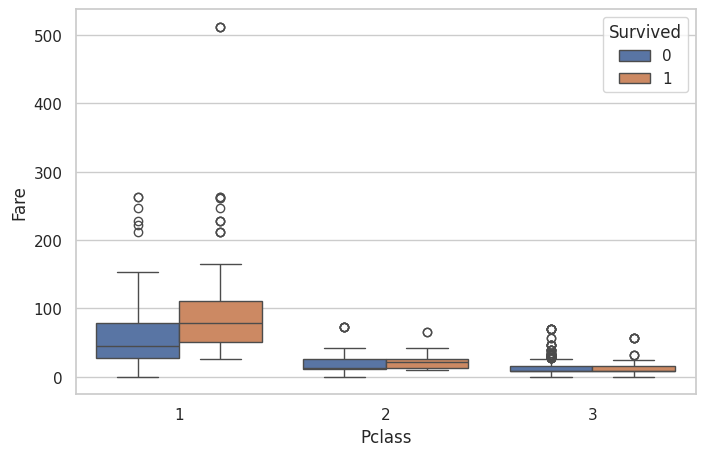

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived'
)

plt.savefig("chart4_fare_boxplot.png")
plt.show()

Chart 5: Correlation Heatmap

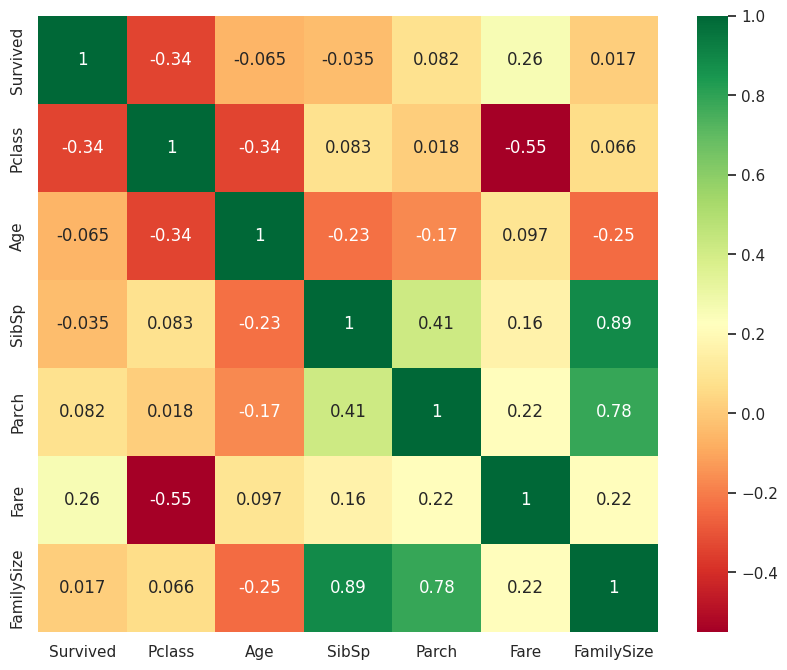

In [15]:
plt.figure(figsize=(10,8))

corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn'
)

plt.savefig("chart5_correlation_heatmap.png")
plt.show()

Chart 6: Scatter Plot

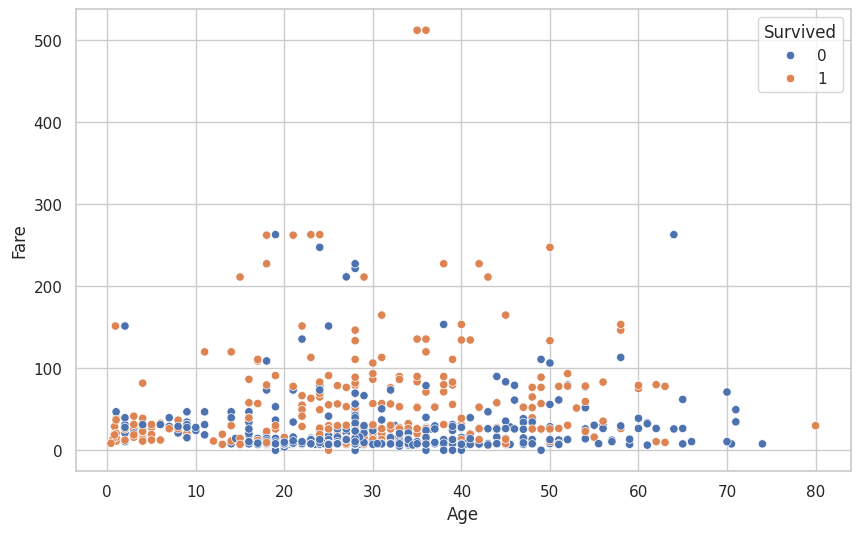

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived'
)

plt.savefig("chart6_age_vs_fare_scatter.png")
plt.show()

Dashboard

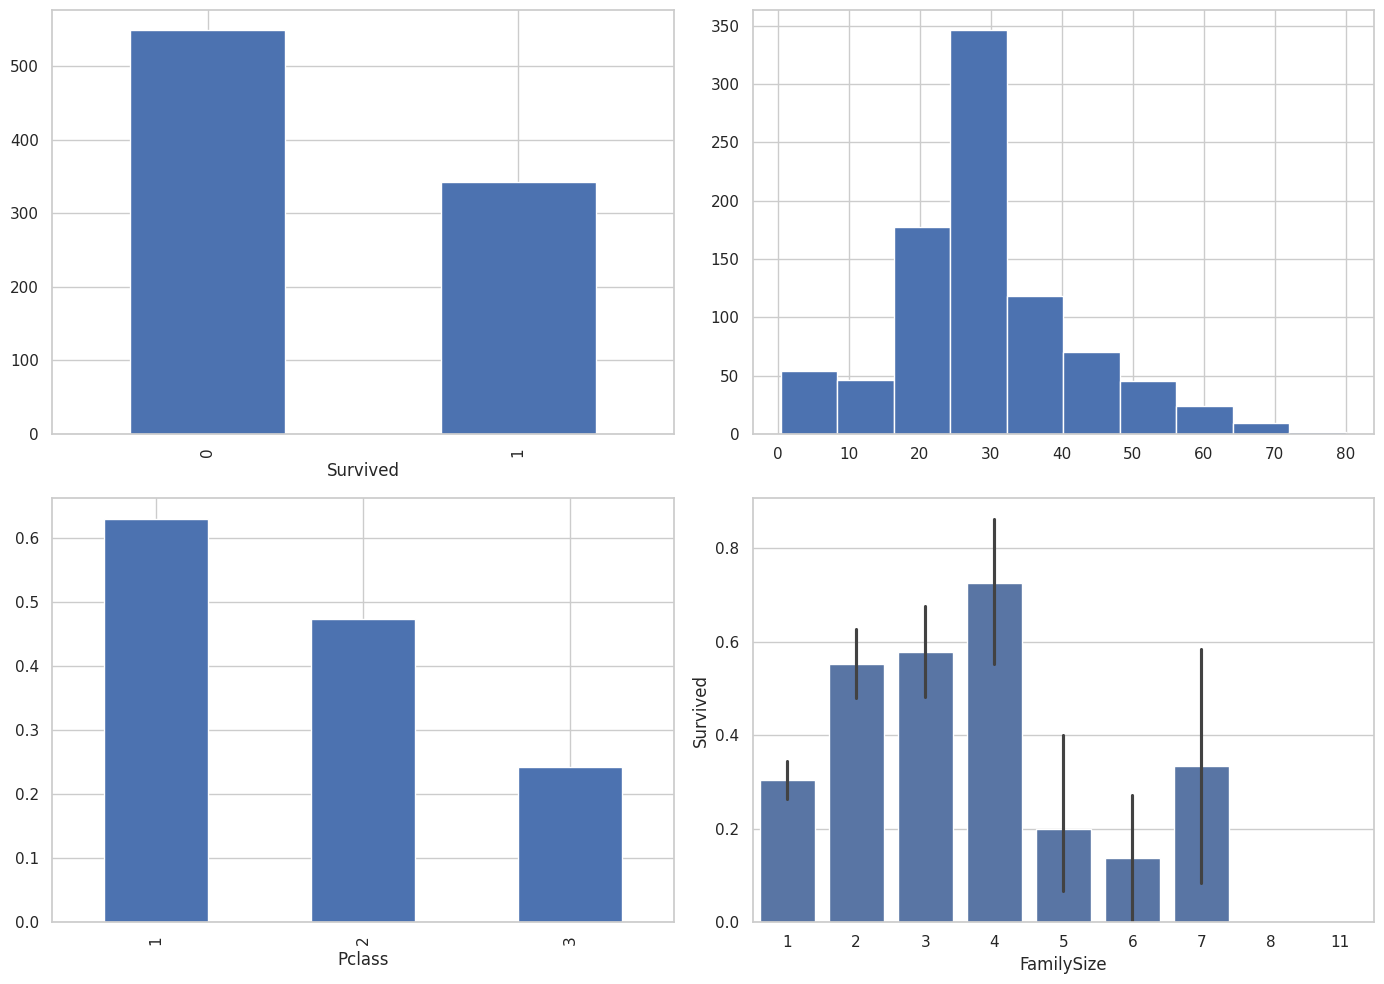

In [17]:
fig, axes = plt.subplots(2,2,figsize=(14,10))

df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0])

df['Age'].hist(ax=axes[0,1])

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1,0])

sns.barplot(
    data=df,
    x='FamilySize',
    y='Survived',
    ax=axes[1,1]
)

plt.tight_layout()

plt.savefig("dashboard_titanic.png")
plt.show()